# Operating-Leverage -- do high-fixed-cost firms earn a premium?
### The Novy-Marx (2011) operating-leverage value channel on a large-cap survivor basket

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Channel: Busted](https://img.shields.io/badge/Channel-Busted-8b949e?style=flat-square)

Robert Novy-Marx argued in 2011 that a firm's *fixed* operating costs act like leverage on the income statement. A firm whose operating costs (cost of goods + SG&A) are large relative to its asset base behaves like a *levered claim on demand*: small revenue swings produce large profit swings, so it carries more operating risk and should earn a premium that overlaps the value effect. We test this **operating-leverage channel** on a fixed large-cap basket using real SEC EDGAR filings.

> This is the plain-language layer. The HAC t-stats, label-shuffle placebo, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: the basket covers only firms still large-cap in 2026. High-fixed-cost firms whose demand collapsed and *failed* are absent -- which matters more than usual, because operating leverage is a *risk* premium that is supposed to pay for exactly those bad states.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))          # study package (operating_leverage/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from operating_leverage import data, strategy as st

# Cache-first: load the study's own EDGAR + price cache; fall back to frozen R.
ol, fwd = data.fetch_panel()
ol = ol.dropna(how="all") if not ol.empty else ol
HAVE_REAL = not ol.empty
if HAVE_REAL:
    h = st.sorted_returns(ol, fwd, n_groups=3)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({len(ol.columns) if HAVE_REAL else 0} names, {len(h) if HAVE_REAL else 0} sort years)")

R = dict(
    n_names=38, n_years=17, start_year=2008, end_year=2024,
    lo_mean=22.3, lo_sharpe=0.99, lo_t=4.68, lo_hit=94,
    mid_mean=16.0, hi_mean=20.1, hi_sharpe=1.3, hi_t=5.96, hi_hit=100,
    mkt_mean=19.5, mkt_sharpe=1.42,
    hedge_mean=-2.14, hedge_sharpe=-0.1, hedge_t=-0.39, hedge_hit=59,
    hi_excess_mean=0.6, hi_excess_t=0.31,
    lo_excess_mean=2.8, lo_excess_t=0.75,
    placebo_p=0.72, shuffle_mean=-0.12, shuffle_std=3.19,
    rand_std=7.8, rand_pct_beaten=54,
    cost_drag=0.2, borrow_drag=0.5, net_mean=-2.84,
    synth_null_t=0.15, synth_06_t=15.16, synth_10_t=25.06,
)
G1  = [36.6, 23.5, 5.5, 9.8, 20.5, 5.3, 13.9, 38.2, 14.9, 24.8, -2.8, 34.4, 15.6, 2.9, 34.2, 6.5, 94.7]
G3  = [47.2, 27.4, 21.4, 14.3, 14.5, 23.3, 10.9, 15.4, 16.5, 29.2, 9.4, 60.9, 5.9, 4.9, 11.1, 0.1, 29.6]
MKT = [35.8, 25.3, 11.7, 13.9, 17.2, 13.6, 8.4, 27.9, 18.3, 22.0, 5.6, 50.6, 8.7, 5.4, 18.2, 3.5, 45.1]
HDG = [10.7, 3.9, 16.0, 4.5, -6.0, 18.0, -3.1, -22.8, 1.6, 4.3, 12.2, 26.6, -9.6, 2.0, -23.1, -6.4, -65.2]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real cache loaded: True (40 names, 17 sort years)


## The answer first

| Question | What the data says |
|---|---|
| Do high-operating-leverage firms outperform low ones? | No -- the hedge is **-2.14%/yr**, slightly the *wrong way*. The two legs earn ~20%/yr each. |
| Is that statistically real? | HAC *t* = -0.39 -- nowhere near |t| >= 2, and negative. The premium is **absent**. |
| Does it beat a coin-flip relabelling? | No -- placebo p = 0.72; a shuffled label beats it 72% of the time. |
| Could you trade it? | No. After costs + short borrow the hedge is **-2.84%/yr net**. |

> **The catch**: operating leverage is a *risk* premium -- it is meant to pay in the bad states where a high-fixed-cost firm's demand collapses. A *survivor* basket deletes exactly those failures, so the surviving high-OL names are the ones whose demand *didn't* collapse. (2024: the low-OL, capital-light megacaps ran +94.7% while the high-OL tercile lagged at +29.6%.)

## 1 - The claim

> *Buy the high-fixed-cost firms. Sell the asset-heavy, capital-light ones. Rebalance annually. The high-operating-leverage firms are riskier -- a levered claim on demand -- and should pay a premium for that risk.*

The signal is one accounting ratio:

- **OL_t** = (COGS_t + SG&A_t) / Total Assets_t

A high OL means the firm's income statement is dominated by operating costs relative to its asset base -- think a thin-margin retailer (rent, wages, logistics) versus a capital-light software platform. Novy-Marx's argument: those fixed costs amplify the effect of demand swings on profits, raising operating risk and expected return. This is the *operating-leverage* channel -- distinct from the *financial*-leverage (balance-sheet debt) anomaly tested in [Study 154](../../154-leverage-anomaly/).

## 2 - So what?

If the operating-leverage effect is real and tradable on large US stocks, it is a low-ML, fundamentals-only strategy needing only public 10-K filings, and it helps *explain* the value premium (value firms tend to have under-utilised assets and high fixed costs). If it only works on small/mid-caps -- or is a selection artefact -- the large-cap test is a cautionary tale about testing a risk premium in a sample with the risk deleted.

## 3 - How would we even know?

Three honesty requirements:

1. **One execution lag.** OL from fiscal year y drives a 12-month return that *starts 4 months after year-end* (when the 10-K is public), entered one trading day later. No same-bar fills, no look-ahead; no partial year is ever stamped.
2. **Placebo + random control.** Shuffle the OL labels within each year; does the real hedge beat its shuffled self? And does the high-OL leg beat a random draw of the same size?
3. **Name the survivorship bias.** The basket is current large-caps. Failed high-fixed-cost firms are absent. Every result is conditional on survival -- and for a *risk* premium, that conditioning is fatal.

## 4 - The teardown

Positive control first: **when we plant a real operating-leverage effect in a synthetic panel, the engine finds it.** That makes the real-data result a statement about the *market* (and the survivor basket), not the method.

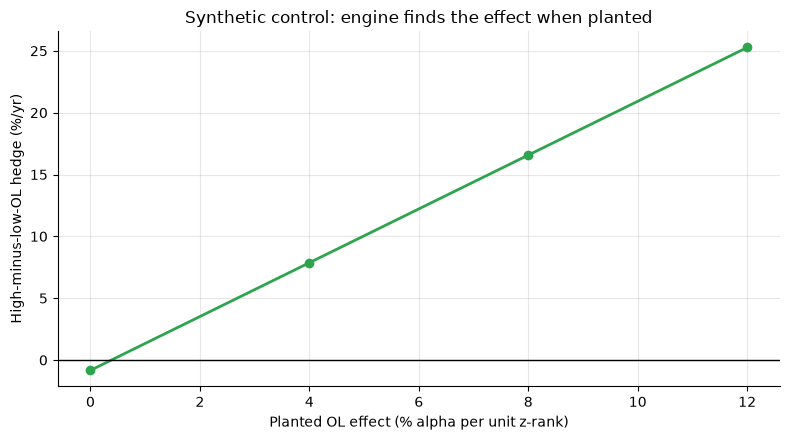

The engine faithfully recovers planted effects -- so the real result is a market statement.


In [2]:
# Synthetic positive control: plant a known OL premium, confirm the engine detects it
premiums = [0.0, 0.04, 0.08, 0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=524)
    hh = st.sorted_returns(s, f, n_groups=3)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([p*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted OL effect (% alpha per unit z-rank)')
ax.set_ylabel('High-minus-low-OL hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted effects -- so the real result is a market statement.')

**Now the real EDGAR panel -- tercile sort on operating leverage:**

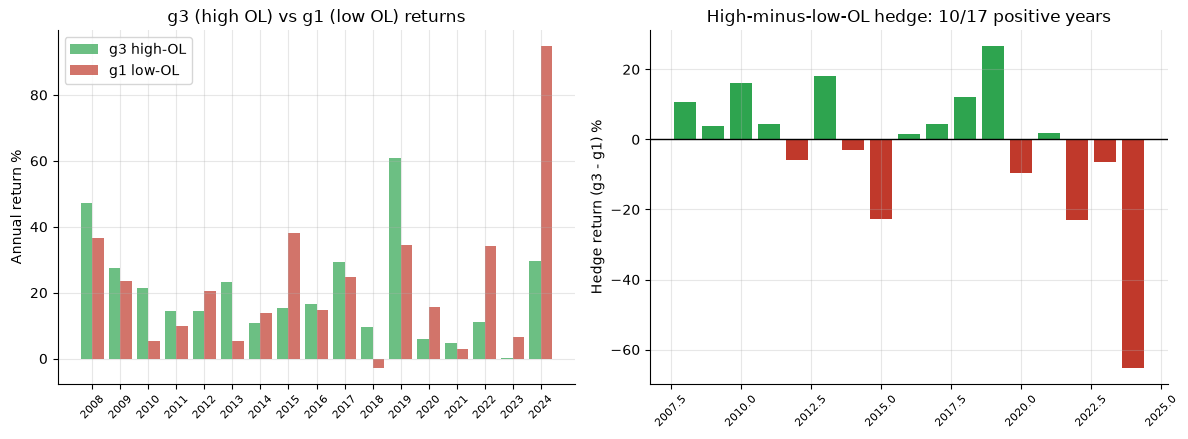

Mean hedge: -2.14%/yr  (frozen R: -2.14%/yr)


In [3]:
if HAVE_REAL:
    g1_vals = h['g1'].values * 100
    g3_vals = h['g3'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = [int(y) for y in h.index.tolist()]
else:
    g1_vals, g3_vals, hdg_vals, years_real = G1, G3, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, g3_vals, label='g3 high-OL', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], g1_vals, label='g1 low-OL', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('g3 (high OL) vs g1 (low OL) returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (g3 - g1) %')
axes[1].set_title(f'High-minus-low-OL hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.2f}%/yr  (frozen R: {R["hedge_mean"]:+.2f}%/yr)')

The high-OL tercile earns **+20.1%/yr** vs the low-OL tercile's **+22.3%/yr** -- a hedge of **-2.14%/yr**, positive in only 59% of years and pointing the *wrong* way. **The predicted premium is absent**: high- and low-operating-leverage firms earn essentially the same return on this survivor basket. Deleting the bad-state failures washes the risk premium out -- and the 2024 megacap melt-up even flips the sign.

## 5 - The verdict

- **Signal -- None.** Hedge -2.14%/yr, HAC *t* = -0.39 (wrong sign); placebo p = 0.72. No signal.
- **Tradability -- Mirage.** No gross edge; **-2.84%/yr net** after costs and short borrow.
- **Operating- vs financial-leverage channel -- Busted.** The operating-leverage channel is no more present than the financial-leverage (debt) channel of [Study 154](../../154-leverage-anomaly/).

## 6 - Could you actually trade it?

No. There is no signal on this basket. Even setting aside survivorship:

1. **Wrong universe.** Novy-Marx (2011) documented the effect on the broad US cross-section, where operating leverage overlaps value and bites hardest among small/mid-caps with limited access to capital. On ~38 heavily-covered large caps it is thin and arbitraged.
2. **A risk premium with the risk deleted.** The high-OL large caps that survived are precisely the firms whose demand *didn't* collapse -- the opposite of the bad-state failures the premium is meant to compensate.
3. **Short the wrong side.** Going short the *low*-OL leg on a survivor basket means shorting the capital-light megacaps -- the decade's biggest winners.

The right conclusion: **explore this in a broad, point-in-time universe before treating the operating-leverage anomaly as tradable.**

## 7 - Going further

- **The right universe.** Novy-Marx (2011) used the broad US cross-section -- thousands of names including small and mid-caps. The large-cap survivor basket here is the wrong test for a risk premium.
- **Financial-leverage cousin.** [Study 154 -- Leverage-Anomaly](../../154-leverage-anomaly/) tests the *balance-sheet debt* channel on a survivor panel; the two leverage channels die together here.
- **Gross-profitability sibling.** [Study 122 -- Gross-Profitability](../../122-gross-profitability/) is Novy-Marx's *other* famous accounting factor, on the same desk infrastructure.

*Think the operating-leverage effect is real in large caps? Fork this, extend to a point-in-time all-US-stock universe that *keeps the failures*, and show |t| >= 2 on the hedge. That's the bar.*